In [ ]:
# Prédiction du prix d'une voiture - First projet ML

J'ai voulu comprendre comment fonctionne le Machine Learning en pratique.
Pour ça j'ai pris un dataset de voitures d'occasion disponible sur kaggle et j'ai essayé de prédire leur prix
à partir de leurs caractéristiques techniques.

In [ ]:
#1. Chargement des données

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data_set.csv", sep=";")
df.head()

,Unnamed: 0,model1,model2,version,price,km,fuel,days_after_pub,CV_fisc,HorseP,...,CO2_g_km,trunk_volume,year,circuilation_days,Length,Nb_option,circuilation_date,month,ID_index,dep_name
0,0,HYUNDAI,I20 (3E GENERATION),III 1.0 T-GDI 100 ACTIVE,16340,47981,Essence,60,5.0,100.0,...,NaN,326.0,2018,864,4.07,15.0,2021-07-08 00:00:00.000000,7,0,17 Charente-Maritime
1,1,RENAULT,MEGANE 4,IV 1.2 TCE 130 ENERGY INTENS,16110,104063,Essence,23,7.0,132.0,...,119.0,384.0,2016,2326,4.36,44.0,2017-07-07 00:00:00.000000,7,1,75 Paris
2,2,PEUGEOT,2008,(2) 1.6 BLUEHDI 100 S&S ALLURE BUSINESS,17720,108405,Diesel,27,5.0,99.0,...,90.0,410.0,2016,1635,4.16,33.0,2019-05-29 00:00:00.000000,5,2,76 Seine-Maritime
3,3,PEUGEOT,208 (2E GENERATION),II 1.5 BLUEHDI 100 S&S ALLURE,24550,30223,Diesel,6,5.0,102.0,...,107.0,311.0,2019,628,4.05,63.0,2022-03-01 00:00:00.000000,3,3,33 Gironde
4,4,VOLKSWAGEN,TIGUAN 2,II 2.0 TDI 150 BLUEMOTION TECHNOLOGY CONFORTLI...,35560,39578,Diesel,44,8.0,150.0,...,123.0,615.0,2019,1235,4.49,38.0,2020-07-02 00:00:00.000000,7,4,55 Meuse


In [ ]:
#2. Exploration des données

Je commence par regarder ce que contient le dataset, combien de colonnes, les types de données, et les valeurs manquantes.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141199 entries, 0 to 141198
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         141199 non-null  int64  
 1   model1             141199 non-null  str    
 2   model2             141199 non-null  str    
 3   version            141199 non-null  str    
 4   price              141199 non-null  int64  
 5   km                 141199 non-null  int64  
 6   fuel               141199 non-null  str    
 7   days_after_pub     141199 non-null  int64  
 8   CV_fisc            140844 non-null  float64
 9   HorseP             140708 non-null  float64
 10  dep                141199 non-null  int64  
 11  warranty_month     141199 non-null  int64  
 12  CT                 141199 non-null  int64  
 13  Crit_Air           135295 non-null  float64
 14  Gearbox_auto       141199 non-null  int64  
 15  L_by_100km         121007 non-null  float64
 16  numbe_seats  

In [5]:
df.describe()
#on peut voir ici qu'il y a des colonnes avec des valeurs manquantes, mais assez difficile à lire ici combien

,Unnamed: 0,price,km,days_after_pub,CV_fisc,HorseP,dep,warranty_month,CT,Crit_Air,...,Euro_stand,first_hand,CO2_g_km,trunk_volume,year,circuilation_days,Length,Nb_option,month,ID_index
count,141199.000000,141199.000000,141199.000000,141199.000000,140844.000000,140708.000000,141199.000000,141199.000000,141199.000000,135295.000000,...,135365.000000,141199.000000,135747.000000,126646.000000,141199.000000,141199.000000,135263.000000,140407.000000,141199.000000,141199.000000
mean,70599.000000,35154.056665,58359.747689,33.221347,8.788646,155.244158,55.036516,13.379542,0.756925,1.508459,...,5.879814,0.489954,125.593074,425.592897,2017.574083,1361.104123,4.452647,43.788622,6.522412,74856.181559
std,40760.784667,38808.688615,46218.940235,22.110782,7.885242,94.594860,25.428682,7.657618,0.428942,0.562028,...,0.428027,0.499901,43.941942,205.032722,3.447948,1211.348632,3.643863,28.083715,3.441787,43074.937480
min,0.000000,1740.000000,1.000000,0.000000,1.000000,5.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,65.000000,1953.000000,-74.000000,0.430000,1.000000,1.000000,0.000000
25%,35299.500000,18960.000000,21638.000000,11.000000,5.000000,105.000000,33.000000,12.000000,1.000000,1.000000,...,6.000000,0.000000,108.000000,311.000000,2016.000000,574.000000,4.120000,20.000000,4.000000,37657.500000
50%,70599.000000,26480.000000,48586.000000,33.000000,7.000000,131.000000,59.000000,12.000000,1.000000,2.000000,...,6.000000,0.000000,122.000000,410.000000,2018.000000,1154.000000,4.370000,39.000000,7.000000,74454.000000
75%,105898.500000,37000.000000,87311.000000,60.000000,8.000000,163.000000,76.000000,12.000000,1.000000,2.000000,...,6.000000,1.000000,137.000000,520.000000,2020.000000,1770.000000,4.590000,61.000000,10.000000,112369.500000
max,141198.000000,793620.000000,580859.000000,60.000000,86.000000,800.000000,95.000000,84.000000,1.000000,5.000000,...,6.000000,1.000000,475.000000,12600.000000,2022.000000,24763.000000,162.400000,214.000000,12.000000,149239.000000


In [6]:
# Quelles colonnes ont des valeurs manquantes ?
df.isnull().sum().sort_values(ascending=False)

L_by_100km           20192
trunk_volume         14553
numbe_seats           6069
Length                5936
Crit_Air              5904
Euro_stand            5834
CO2_g_km              5452
Nb_option              792
HorseP                 491
CV_fisc                355
doors_nb               118
month                    0
circuilation_date        0
circuilation_days        0
year                     0
ID_index                 0
first_hand               0
Unnamed: 0               0
model1                   0
Gearbox_auto             0
CT                       0
warranty_month           0
dep                      0
days_after_pub           0
fuel                     0
km                       0
price                    0
version                  0
model2                   0
dep_name                 0
dtype: int64

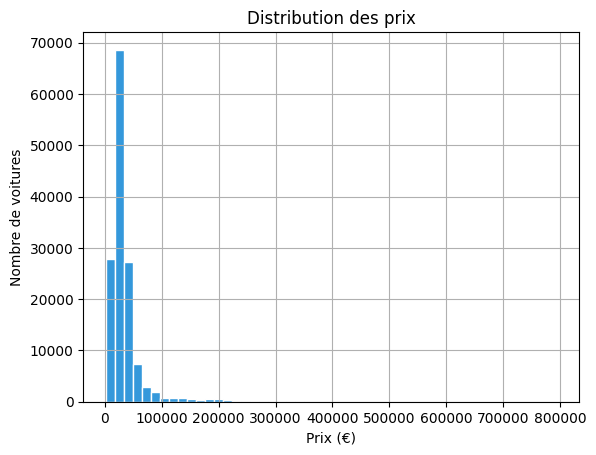

In [7]:
# Distribution des prix, est ce que c'est équilibré ?
df["price"].hist(bins=50, color="#3498db", edgecolor="white")
plt.title("Distribution des prix")
plt.xlabel("Prix (€)")
plt.ylabel("Nombre de voitures")
plt.show()

In [ ]:
On voit que la majorité des voitures sont entre 5 000€ et 40 000€,
avec quelques voitures très chères qui tirent la distribution vers la droite.

In [ ]:
#3. Nettoyage des données

Je supprime les colonnes inutiles et je remplace les valeurs manquantes par la médiane.
J'ai choisi la médiane plutôt que la moyenne car elle est moins sensible aux valeurs extrêmes.

In [8]:
df = df.drop(columns=["Unnamed: 0", "L_by_100km", "trunk_volume"])

df = df.fillna(df.median(numeric_only=True))

print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Valeurs manquantes restantes : 0


In [9]:
df = df.sample(30000, random_state=0)
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#4. Entraînement du modèle

J'utilise un Random Forest ,c'est un algorithme qui combine plusieurs arbres de décision
pour faire une prédiction plus robuste.

Je garde seulement 5 features techniques qui varie le prix pour faire la prédiction.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ["km", "HorseP", "year", "CV_fisc", "CO2_g_km"]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = RandomForestRegressor(
    n_estimators=20,
    max_depth=12,
    random_state=0,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Modèle entraîné")

Modèle entraîné


In [ ]:
#5. Quelles variables influencent le plus le prix ?

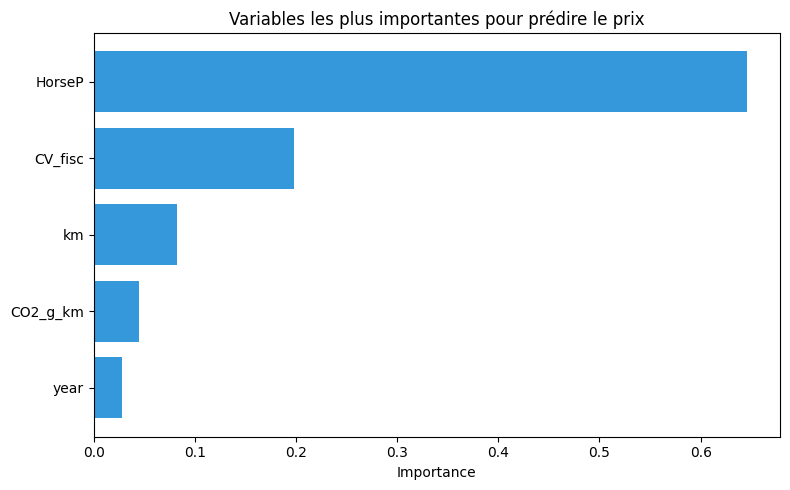

In [11]:
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="#3498db")
plt.xlabel("Importance")
plt.title("Variables les plus importantes pour prédire le prix")
plt.tight_layout()
plt.show()

In [ ]:
La puissance moteur et la puissance fiscal sont les deux variables qui influencent le plus le prix. 
Donc j'ai pris les bonnes variables pour entrainé mon model.

In [ ]:
#6. Évaluation du modèle

Je mesure les performances avec deux métriques :
- R² : est-ce que le modèle capture bien la variabilité des prix ?
- MAE : en moyenne, de combien d'euros le modèle se trompe-t-il ?

In [12]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²  = {r2:.4f}")
print(f"MAE = {mae:,.0f} €")

R²  = 0.9545
MAE = 4,359 €


In [ ]:
R² = 0.97 et MAE = 4 160€
Donc résultat assez bon 

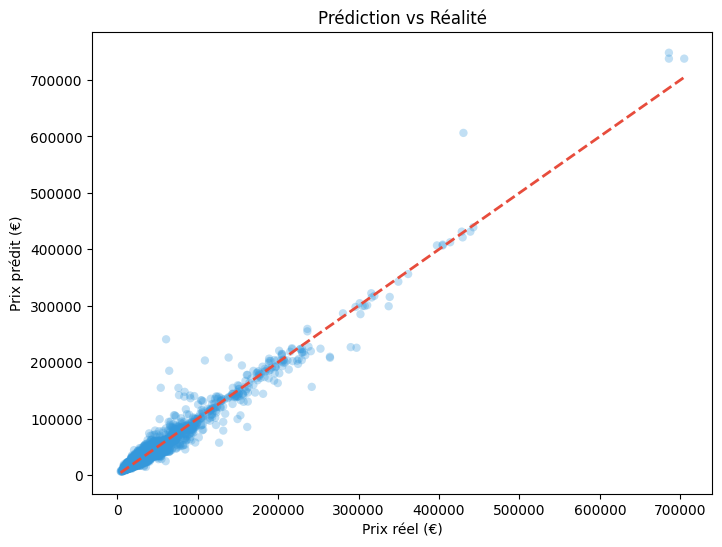

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="#3498db", edgecolors="none")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="#e74c3c", linewidth=2, linestyle="--"
)
plt.xlabel("Prix réel (€)")
plt.ylabel("Prix prédit (€)")
plt.title("Prédiction vs Réalité")
plt.show()

In [ ]:
Les résultats sont donc assez bons pour un premier modèle avec seulement 5 variables.